In [2]:
# Import necessary libraries
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Login to wandb (if not already logged in)
wandb.login()

# Define the project and entity
project_name = "Negatives_review"
entity_name = "ntourne"

# Initialize the wandb API
api = wandb.Api()

# Fetch all runs from the project
runs = api.runs(f"{entity_name}/{project_name}")

/data/home/natant/anaconda3/envs/Negs2/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/data/home/natant/anaconda3/envs/Negs2/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happ

In [3]:
import json
# Initialize a list to store results
results = []

# Iterate through runs and extract metrics
for run in runs:
    # Get the summary metrics, config, and name of the run
    summary = run.summary._json_dict
    if isinstance(summary, str):
        summary = json.loads(summary)
    config = run.config
    if isinstance(config, str):
        config = json.loads(config)
    name = run.name
    
    # Combine the data into a single dictionary
    run_data = {
        "run_name": name,
        "TF": config.get("TF")["value"],
        "celltype": config.get("celltype")["value"],
        "neg_mode": [config.get("neg_mode")["value"] if "neg_mode" in config else "HQ training"][0],
        "cross_val_set": config.get("cross_val_set")["value"],
        "group_name": config.get("group_name")["value"],
        "AUROC": summary.get("test_AUROC"),
        "AUROC_HQ": summary.get("test_AUROC_HQ"),
        "val_loss": summary.get("val_loss"),
        "Accuracy": summary.get("test_Accuracy"),
        "Accuracy_HQ": summary.get("test_Accuracy_HQ"),
        "Average_Precision": summary.get("test_Average_precision"),
        "Average_Precision_HQ": summary.get("test_Average_precision_HQ"),
        "Matthews_Correlation": summary.get("test_Matthews_corr_coef"),
        "Matthews_Correlation_HQ": summary.get("test_Matthews_corr_coef_HQ"),
        "Precision": summary.get("test_Precision"),
        "Precision_HQ": summary.get("test_Precision_HQ"),
        "Specificity": summary.get("test_Specificity"),
        "Specificity_HQ": summary.get("test_Specificity_HQ")
    }
    results.append(run_data)

# Convert the results into a DataFrame


In [4]:
results_df = pd.DataFrame(results)
results_df["test_celltype"] = results_df["celltype"]
results_df.loc[results_df["group_name"] == "Review_cross_cell_perf", "celltype"] = "GM12878"
results_df = results_df[results_df["celltype"] == "GM12878"]
results_df = results_df[results_df['group_name'].isin(["Review_rerun_1", "Review_rerun_1_HQ", "Review_rerun_1_CT", "Review_cross_cell_perf"])] # select the right groups
# HQ_results = pd.DataFrame(results)
# HQ_results = HQ_results[HQ_results['group_name'] == "full_run_3_HQ"]
# HQ_results["neg_mode"] = "HQ training"
# HQ_results = HQ_results.rename(columns={"AUROC": "AUROC_HQ", "AUROC_HQ": "AUROC"})
# HQ_results = HQ_results[HQ_results['celltype'].isin(['A549', 'GM12878', 'K562', 'HepG2'])] # only the right celltypes
# Merge results_df with HQ_results, aligning columns as needed
# results_df = pd.concat([results_df, HQ_results], ignore_index=True)

In [5]:
# Exclude rows where neg_mode is 'HQ training' before checking for NaNs in AUROC
mask = results_df["neg_mode"] != "HQ training"
num_nans = results_df.loc[mask, "AUROC"].isna().sum()
print(f"Number of NaNs in AUROC (excluding HQ training): {num_nans}")
results_df.loc[mask & results_df["AUROC"].isna()]

Number of NaNs in AUROC (excluding HQ training): 0


,run_name,TF,celltype,neg_mode,cross_val_set,group_name,AUROC,AUROC_HQ,val_loss,Accuracy,Accuracy_HQ,Average_Precision,Average_Precision_HQ,Matthews_Correlation,Matthews_Correlation_HQ,Precision,Precision_HQ,Specificity,Specificity_HQ,test_celltype


In [6]:
# Filter out entries where AUROC_HQ == 0 -> probably an issue with the cross val split 
filtered_out_count = results_df[(results_df['AUROC_HQ'] == 0) | (results_df['AUROC_HQ'].isna())].shape[0]

# Filter the DataFrame to exclude these entries
#results_df = results_df[~((results_df['AUROC_HQ'] == 0) | (results_df['AUROC_HQ'].isna()))]

# Print the count of filtered-out entries
print(f"Number of entries where AUROC_HQ == 0 or NaN: {filtered_out_count}")

Number of entries where AUROC_HQ == 0 or NaN: 564


In [7]:
results_df["celltype_TF"] = results_df["celltype"]+"_"+results_df["TF"]
output = results_df["celltype_TF"].value_counts()
output.to_dict()

{'GM12878_CTCF': 144,
 'GM12878_YY1_(SC-281)': 144,
 'GM12878_ELF1_(SC-631)': 144,
 'GM12878_USF-1': 144,
 'GM12878_ATF3': 144,
 'GM12878_Max': 144,
 'GM12878_ZBTB33': 144,
 'GM12878_TBP': 108,
 'GM12878_ZNF274': 108,
 'GM12878_SP1': 108,
 'GM12878_MAZ_(ab85725)': 108,
 'GM12878_Mxi1_(AF4185)': 108,
 'GM12878_USF2': 108,
 'GM12878_CEBPB_(SC-150)': 108,
 'GM12878_ETS1': 108,
 'GM12878_JunD': 108,
 'GM12878_TCF12': 108,
 'GM12878_SIX5': 108,
 'GM12878_RFX5_(200-401-194)': 108,
 'GM12878_SRF': 108,
 'GM12878_Nrf1': 108,
 'GM12878_Egr-1': 72,
 'GM12878_STAT5A_(SC-74442)': 72,
 'GM12878_RXRA': 72,
 'GM12878_Znf143_(16618-1-AP)': 72,
 'GM12878_NF-YB': 72,
 'GM12878_ELK1_(1277-1)': 72,
 'GM12878_MEF2A': 72,
 'GM12878_NF-YA': 72,
 'GM12878_NFIC_(SC-81335)': 72,
 'GM12878_ATF2_(SC-81188)': 36,
 'GM12878_ZEB1_(SC-25388)': 36,
 'GM12878_Pbx3': 36,
 'GM12878_FOXM1_(SC-502)': 36,
 'GM12878_IKZF1_(IkN)_(UCLA)': 36,
 'GM12878_ZZZ3': 36}

In [8]:
results_df["celltype"].value_counts()

celltype
GM12878    3384
Name: count, dtype: int64

In [9]:
results_df["TF-neg_mode"] = results_df["TF"]+"_"+results_df["neg_mode"]
results_df["TF-neg_mode-celltype"] = results_df["TF"]+"_"+results_df["neg_mode"]+"_"+results_df["celltype"]
results_df["TF-neg_mode-celltype"].value_counts()[results_df["TF-neg_mode-celltype"].value_counts() <6]

Series([], Name: count, dtype: int64)

In [10]:
# Get all possible combinations that should exist
all_combinations = []
for tf in results_df['TF'].unique():
    for celltype in results_df['celltype'].unique():
        for neg_mode in results_df['neg_mode'].unique():
            # Skip combinations that don't exist at all (not all TFs exist in all celltypes)
            if results_df[(results_df['TF'] == tf) & 
                          (results_df['celltype'] == celltype) & 
                          (results_df['neg_mode'] == neg_mode)].shape[0] > 0:
                for cv_fold in range(6):  # 6 folds: 0-5
                    all_combinations.append({
                        'TF': tf,
                        'celltype': celltype,
                        'neg_mode': neg_mode,
                        'cross_val_set': cv_fold
                    })

# Convert to DataFrame
expected_df = pd.DataFrame(all_combinations)

# Merge with actual runs to find missing ones
actual_runs = results_df[['TF', 'celltype', 'neg_mode', 'cross_val_set']].drop_duplicates()
missing_runs = pd.merge(
    expected_df, 
    actual_runs, 
    on=['TF', 'celltype', 'neg_mode', 'cross_val_set'], 
    how='left', 
    indicator=True
)

# Filter to only missing runs
missing_runs = missing_runs[missing_runs['_merge'] == 'left_only'].drop(columns=['_merge'])

# Add group_name based on neg_mode
missing_runs['group_name'] = missing_runs['neg_mode'].apply(
    lambda x: 'full_run_3_HQ' if x == 'HQ training' else 'full_run_3'
)

# Sort for better readability
missing_runs = missing_runs.sort_values(['celltype', 'TF', 'neg_mode', 'cross_val_set']).reset_index(drop=True)

In [11]:
missing_runs

,TF,celltype,neg_mode,cross_val_set,group_name


In [12]:
import pickle

with open("/data/home/natant/Negatives/testing_ground/20250613_NUMBER_OF_POSITIVES_PER_GROUP.pkl", "rb") as f:
    number_of_positives = pickle.load(f)
# Convert the nested dictionary 'number_of_positives' into a pandas DataFrame
number_of_positives_df = (
    pd.DataFrame([
        {"celltype": ct, "TF": tf, "positives 1": vals[0], "positives 2": vals[1], "positives 3": vals[2]}
        for ct, tf_dict in number_of_positives.items()
        for tf, vals in tf_dict.items()
    ])
)
number_of_positives_df

,celltype,TF,positives 1,positives 2,positives 3
0,MCF-7,CTCF,7124,5733,8144
1,MCF-7,TCF7L2,2909,2949,4439
2,MCF-7,ZNF217,2911,2775,4259
3,MCF-7,GATA3_(SC-268),1853,1606,2624
4,GM12878,CTCF,12222,12053,15832
...,...,...,...,...,...
127,A549,USF-1,2170,2457,3821
128,A549,ETS1,1535,1503,2503
129,A549,SIX5,1488,1318,2109
130,A549,ZBTB33,1896,2039,3222


In [13]:
from itertools import permutations
all_orderings = list(permutations(["part1", "part2", "part3"]))
ordering_dict = {i: ordering[0] for i, ordering in enumerate(all_orderings)}
# Map cross_val_set to the corresponding positives column using two dictionaries
crossval_to_part = ordering_dict  # e.g., {0: 'part1', 1: 'part1', 2: 'part2', ...}
part_to_col = {"part1": "positives 1", "part2": "positives 2", "part3": "positives 3"}

def lookup_num_training_positives(row):
    part = crossval_to_part[int(row['cross_val_set'])]
    part_col = part_to_col.get(part)
    match = number_of_positives_df[
        (number_of_positives_df['celltype'] == row['celltype']) &
        (number_of_positives_df['TF'] == row['TF'])
    ]
    if not match.empty and part_col is not None:
        return match.iloc[0][part_col]
    else:
        return np.nan

results_df["num_training_positives"] = results_df.apply(lookup_num_training_positives, axis=1)


In [14]:
# Group by TF, celltype, and neg_mode, then average AUROC and AUROC_HQ
grouped_avg = results_df.groupby(['TF', 'celltype', 'neg_mode', "test_celltype"], as_index=False)[['AUROC', 'AUROC_HQ', 'num_training_positives', 'Accuracy', 'Accuracy_HQ','Average_Precision', 'Average_Precision_HQ', 'Matthews_Correlation', 'Matthews_Correlation_HQ', 'Precision', 'Precision_HQ', 'Specificity','Specificity_HQ']].mean()
grouped_avg["TF-neg_mode"] = grouped_avg["TF"] + "-" + grouped_avg["neg_mode"]
grouped_avg

metrics = [
    ('AUROC', 'AUROC_value', 'auroc_metric'),
    ('Average_Precision', 'Average_Precision_value', 'Average_Precision_metric'),
    ('Accuracy', 'Accuracy_value', 'Accuracy_metric'),
    ('Matthews_Correlation', 'Matthews_Correlation_value', 'Matthews_Correlation_metric'),
    ('Precision', 'Precision_value', 'Precision_metric'),
    ('Specificity', 'Specificity_value', 'Specificity_metric')
]
for metric, _, _ in metrics:
    grouped_avg.loc[grouped_avg["neg_mode"] == "HQ training",str(metric+"_HQ")] = grouped_avg[grouped_avg["neg_mode"] == "HQ training"][metric]
    grouped_avg.loc[grouped_avg["neg_mode"] == "HQ training",metric] = np.nan

In [15]:
grouped_avg

,TF,celltype,neg_mode,test_celltype,AUROC,AUROC_HQ,num_training_positives,Accuracy,Accuracy_HQ,Average_Precision,Average_Precision_HQ,Matthews_Correlation,Matthews_Correlation_HQ,Precision,Precision_HQ,Specificity,Specificity_HQ,TF-neg_mode
0,ATF2_(SC-81188),GM12878,HQ training,GM12878,NaN,0.722720,7830.000000,NaN,0.540680,NaN,0.156240,NaN,0.172795,NaN,0.605305,NaN,0.997880,ATF2_(SC-81188)-HQ training
1,ATF2_(SC-81188),GM12878,celltype,GM12878,0.640860,0.621152,7830.000000,0.564521,0.740478,0.612849,0.097783,0.215093,0.080256,0.814242,0.212051,1.000000,0.999978,ATF2_(SC-81188)-celltype
2,ATF2_(SC-81188),GM12878,dinucl_sampled,GM12878,0.791551,0.680566,7830.000000,0.628926,0.241014,0.796392,0.127558,0.445820,0.126325,0.958723,0.336112,0.999639,0.997558,ATF2_(SC-81188)-dinucl_sampled
3,ATF2_(SC-81188),GM12878,dinucl_shuffled,GM12878,0.783179,0.613966,7830.000000,0.679873,0.532981,0.770913,0.096060,0.429311,0.075938,0.913489,0.147041,1.000000,0.999442,ATF2_(SC-81188)-dinucl_shuffled
4,ATF2_(SC-81188),GM12878,neighbors,GM12878,0.699562,0.646343,7830.000000,0.545694,0.803147,0.685676,0.110032,0.295197,0.104699,0.801468,0.155231,1.000000,1.000000,ATF2_(SC-81188)-neighbors
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
559,Znf143_(16618-1-AP),GM12878,dinucl_shuffled,K562,0.858841,0.808754,6672.666667,0.792883,0.780749,0.885748,0.359530,0.600085,0.305285,0.960366,0.454605,0.982117,0.963896,Znf143_(16618-1-AP)-dinucl_shuffled
560,Znf143_(16618-1-AP),GM12878,neighbors,GM12878,0.929617,0.907919,6672.666667,0.781645,0.657169,0.940076,0.472015,0.717850,0.412519,0.979830,0.607143,0.982932,0.969259,Znf143_(16618-1-AP)-neighbors
561,Znf143_(16618-1-AP),GM12878,neighbors,K562,0.859304,0.818180,6672.666667,0.795081,0.822522,0.889643,0.413866,0.607913,0.349631,0.978533,0.627064,0.984898,0.971019,Znf143_(16618-1-AP)-neighbors
562,Znf143_(16618-1-AP),GM12878,shuffled,GM12878,0.959202,0.783736,6672.666667,0.829556,0.282228,0.965809,0.268662,0.803640,0.129799,0.982464,0.251866,0.985282,0.806186,Znf143_(16618-1-AP)-shuffled


In [16]:
grouped_avg["test_celltype"].value_counts()

test_celltype
GM12878    216
K562       162
HepG2      126
A549        60
Name: count, dtype: int64

In [17]:

grouped_avg["neg_mode"].replace({"dinucl_shuffled": "Dinucl shuffled", "dinucl_sampled": "Genome sampled", "shuffled": "Shuffled", "neighbors": "Neighborhood Sampled", "celltype": "Cell Line Sampled"} , inplace=True)
grouped_avg = grouped_avg[grouped_avg["TF"] != "ZNF274"]


/tmp/ipykernel_3065347/3628895519.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  grouped_avg["neg_mode"].replace({"dinucl_shuffled": "Dinucl shuffled", "dinucl_sampled": "Genome sampled", "shuffled": "Shuffled", "neighbors": "Neighborhood Sampled", "celltype": "Cell Line Sampled"} , inplace=True)


In [48]:
plt.rcParams["axes.titlelocation"] = "center"

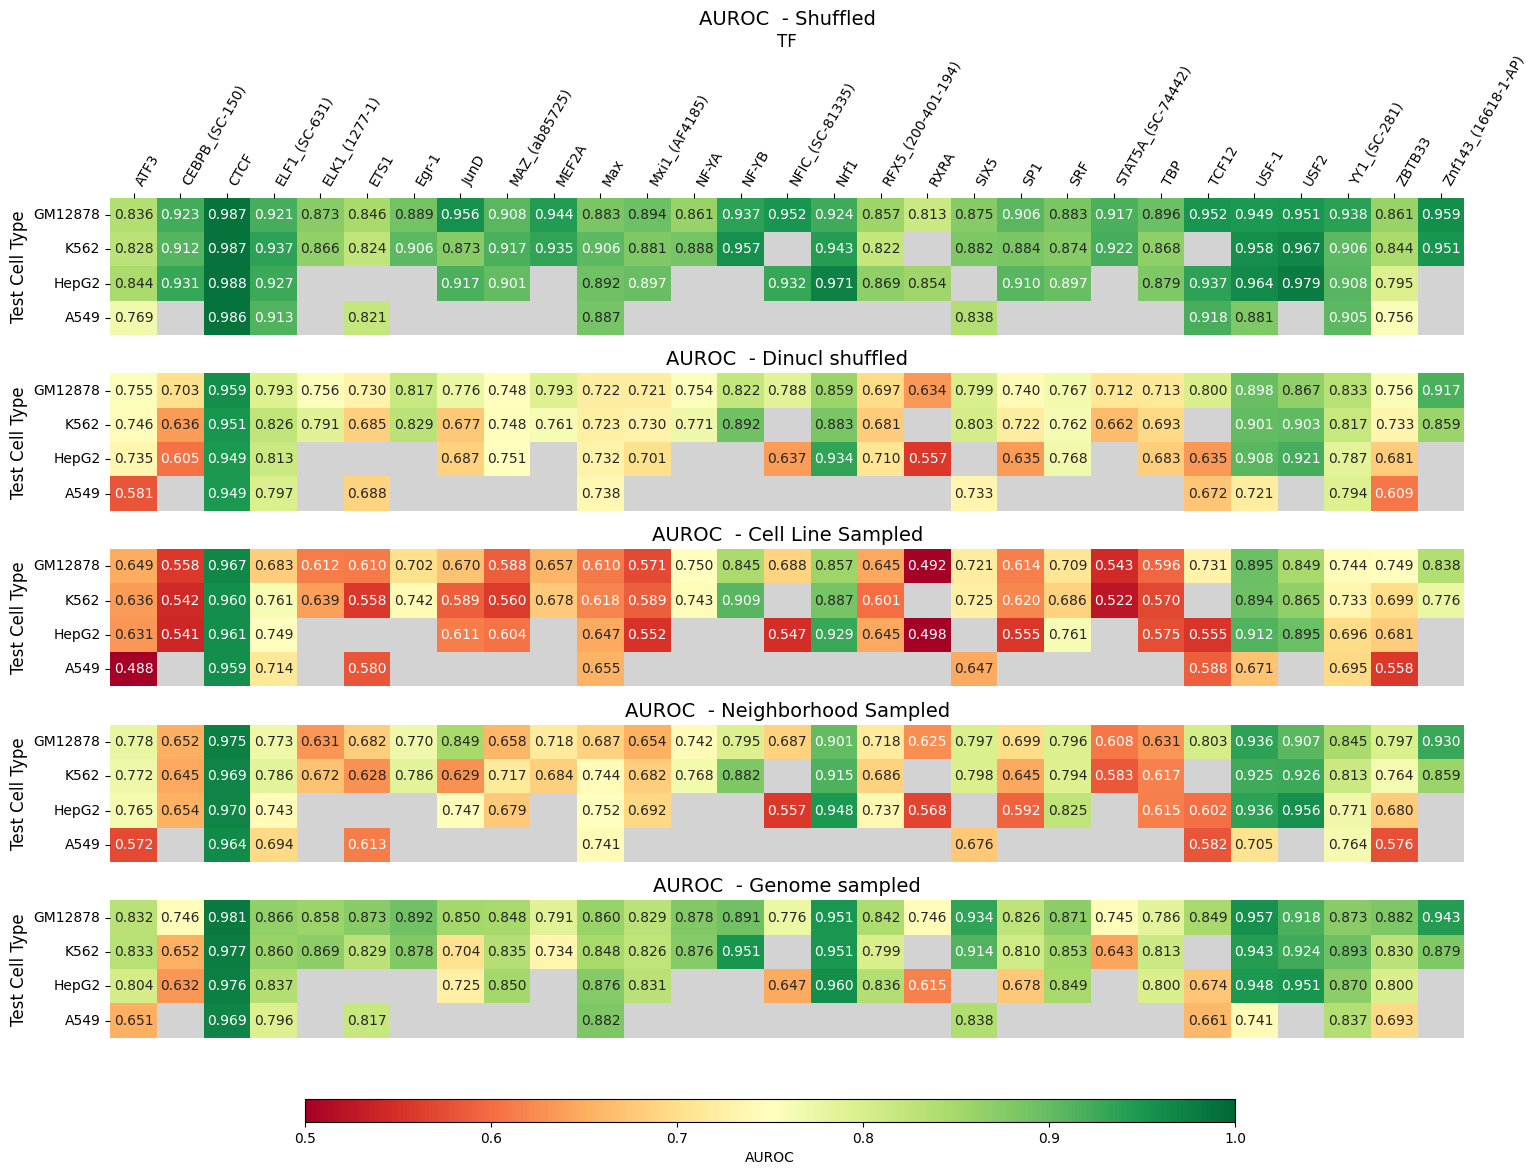

In [49]:
# Get unique neg_modes
neg_modes = ["Shuffled", "Dinucl shuffled", "Cell Line Sampled", "Neighborhood Sampled", "Genome sampled"]
metric = "AUROC"

# Option to filter TFs with data in at least N cell types
min_celltypes = 2  # Set to None to disable filtering, or an integer (e.g., 2, 3, 4)

# Create subplots - one row per neg_mode, shared x-axis
fig, axes = plt.subplots(len(neg_modes), 1, figsize=(15.5, 2.3 * len(neg_modes)), sharex=True)

# If only one neg_mode, axes won't be an array, so wrap it
if len(neg_modes) == 1:
    axes = [axes]

im = None  # will hold the mappable for the global colorbar

# Create a heatmap for each neg_mode
for idx, neg_mode in enumerate(neg_modes):
    # Filter data for this neg_mode
    filtered_df = grouped_avg[grouped_avg['neg_mode'] == neg_mode]
    
    # Create pivot table with TF as columns and test_celltype as rows
    heatmap_data = filtered_df.pivot_table(
        values=metric,
        index='test_celltype',
        columns='TF',
        aggfunc='mean'
    )
    
    # Filter TFs based on minimum cell type requirement
    if min_celltypes is not None:
        tfs_to_keep = heatmap_data.columns[heatmap_data.notna().sum() >= min_celltypes]
        heatmap_data = heatmap_data[tfs_to_keep]
    
    # Reorder rows with specified order
    desired_order = ['GM12878', 'K562', 'HepG2', 'A549']
    existing_celltypes = [ct for ct in desired_order if ct in heatmap_data.index]
    heatmap_data = heatmap_data.reindex(existing_celltypes)
    
    # Create heatmap WITHOUT individual colorbars
    im = sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        ax=axes[idx],
        vmin=0.5,
        vmax=1.0,
        mask=heatmap_data.isna(),
        cbar=False
    )
    
    # Fill grey for missing values
    axes[idx].patch.set_facecolor('lightgrey')
    
    # Only move x-axis labels to top for the first subplot
    if idx == 0:
        axes[idx].xaxis.tick_top()
        axes[idx].xaxis.set_label_position('top')
        axes[idx].set_xlabel('TF', fontsize=12)
        axes[idx].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
        # Rotate labels 90 degrees
        plt.setp(axes[idx].get_xticklabels(), rotation=60, ha='left')
    else:
        axes[idx].set_xlabel('')
        axes[idx].tick_params(bottom=False, labelbottom=False, top=False, labeltop=False)
    
    # Centered titles
    axes[idx].set_title(f'{metric}  - {neg_mode}', fontsize=14, loc='center')
    axes[idx].set_ylabel('Test Cell Type', fontsize=12)

# Add a single colorbar at the bottom using the last heatmap's mappable
fig.tight_layout(rect=[0, 0.08, 1, 1])  # leave space at bottom for cbar

cbar_ax = fig.add_axes([0.2, 0.02, 0.6, 0.02])  # [left, bottom, width, height] in figure coords
cbar = fig.colorbar(im.collections[0], cax=cbar_ax, orientation='horizontal')
cbar.set_label(metric)

plt.savefig("/data/home/natant/Negatives/figures/Cross_cell_line_AUROC_heatmaps.eps",
            format="eps", bbox_inches="tight")
plt.show()

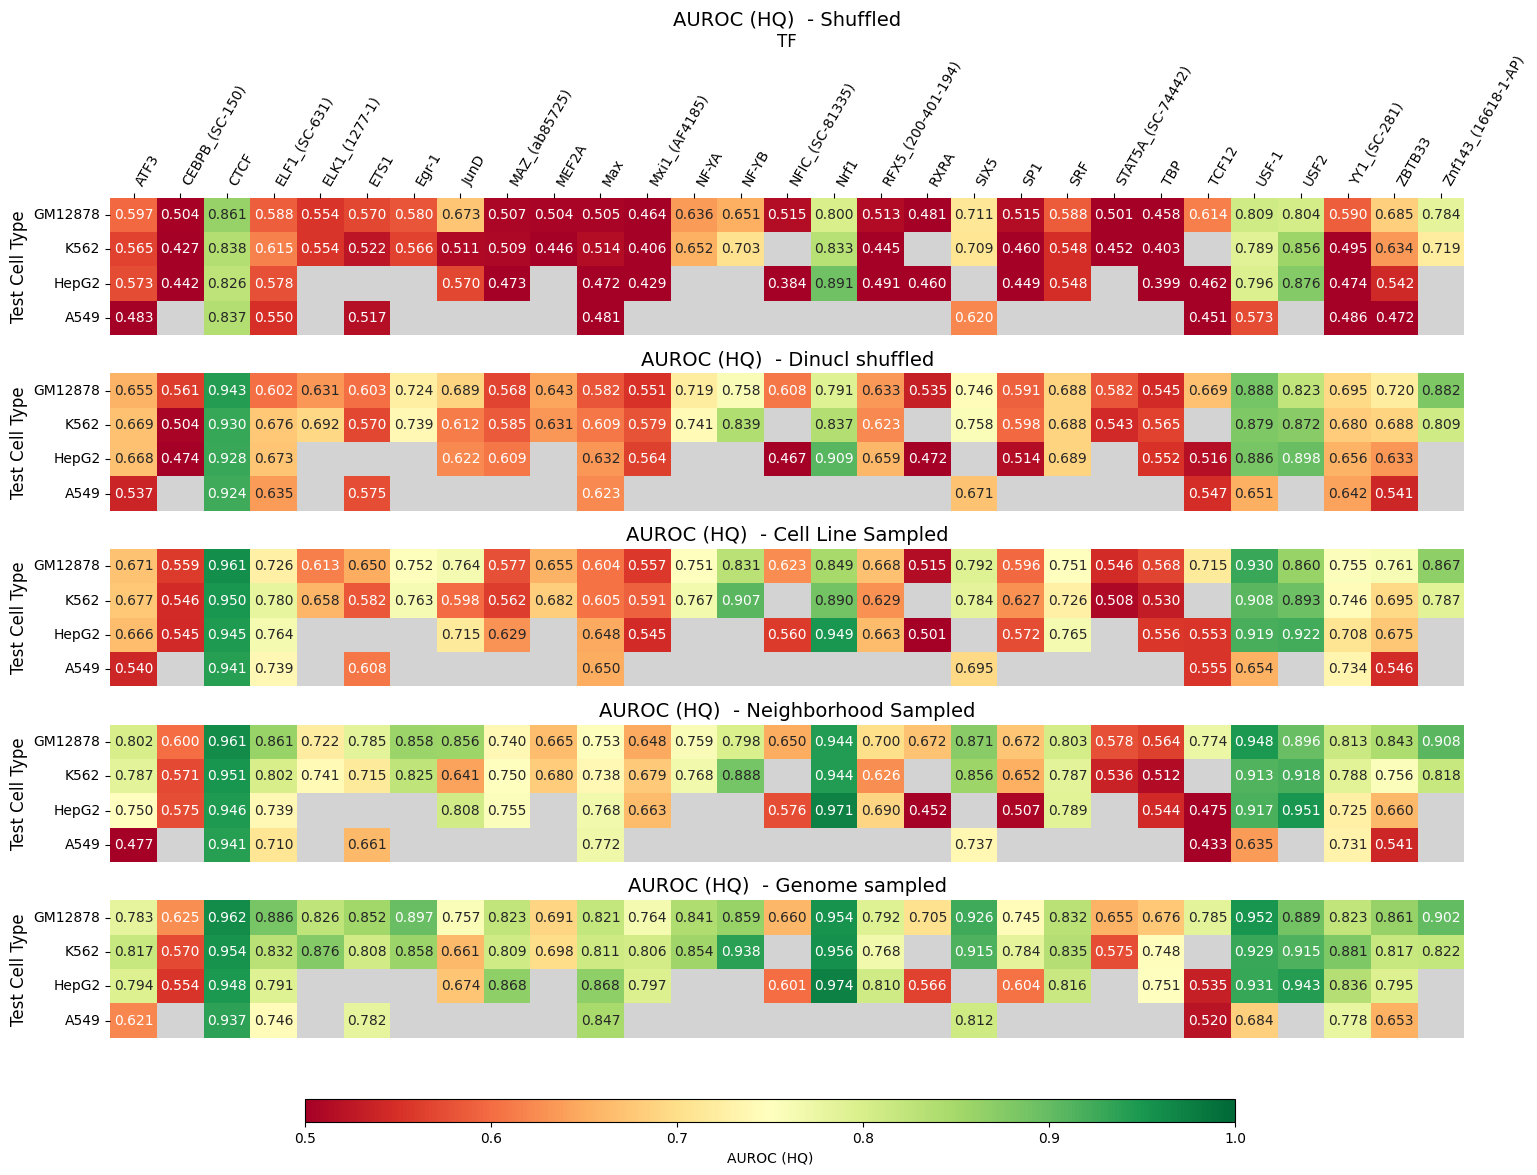

In [51]:
# Get unique neg_modes
neg_modes = ["Shuffled", "Dinucl shuffled", "Cell Line Sampled", "Neighborhood Sampled", "Genome sampled"]
metric = "AUROC_HQ"

# Option to filter TFs with data in at least N cell types
min_celltypes = 2  # Set to None to disable filtering, or an integer (e.g., 2, 3, 4)

# Create subplots - one row per neg_mode, shared x-axis
fig, axes = plt.subplots(len(neg_modes), 1, figsize=(15.5, 2.3 * len(neg_modes)), sharex=True)

# If only one neg_mode, axes won't be an array, so wrap it
if len(neg_modes) == 1:
    axes = [axes]

im = None  # will hold the mappable for the global colorbar

# Create a heatmap for each neg_mode
for idx, neg_mode in enumerate(neg_modes):
    # Filter data for this neg_mode
    filtered_df = grouped_avg[grouped_avg['neg_mode'] == neg_mode]
    
    # Create pivot table with TF as columns and test_celltype as rows
    heatmap_data = filtered_df.pivot_table(
        values=metric,
        index='test_celltype',
        columns='TF',
        aggfunc='mean'
    )
    
    # Filter TFs based on minimum cell type requirement
    if min_celltypes is not None:
        tfs_to_keep = heatmap_data.columns[heatmap_data.notna().sum() >= min_celltypes]
        heatmap_data = heatmap_data[tfs_to_keep]
    
    # Reorder rows with specified order
    desired_order = ['GM12878', 'K562', 'HepG2', 'A549']
    existing_celltypes = [ct for ct in desired_order if ct in heatmap_data.index]
    heatmap_data = heatmap_data.reindex(existing_celltypes)
    
    # Create heatmap WITHOUT individual colorbars
    im = sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        ax=axes[idx],
        vmin=0.5,
        vmax=1.0,
        mask=heatmap_data.isna(),
        cbar=False
    )
    
    # Fill grey for missing values
    axes[idx].patch.set_facecolor('lightgrey')
    
    # Only move x-axis labels to top for the first subplot
    if idx == 0:
        axes[idx].xaxis.tick_top()
        axes[idx].xaxis.set_label_position('top')
        axes[idx].set_xlabel('TF', fontsize=12)
        axes[idx].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
        # Rotate labels 90 degrees
        plt.setp(axes[idx].get_xticklabels(), rotation=60, ha='left')
    else:
        axes[idx].set_xlabel('')
        axes[idx].tick_params(bottom=False, labelbottom=False, top=False, labeltop=False)
    
    # Centered titles
    axes[idx].set_title(f'AUROC (HQ)  - {neg_mode}', fontsize=14, loc='center')
    axes[idx].set_ylabel('Test Cell Type', fontsize=12)

# Add a single colorbar at the bottom using the last heatmap's mappable
fig.tight_layout(rect=[0, 0.08, 1, 1])  # leave space at bottom for cbar

cbar_ax = fig.add_axes([0.2, 0.02, 0.6, 0.02])  # [left, bottom, width, height] in figure coords
cbar = fig.colorbar(im.collections[0], cax=cbar_ax, orientation='horizontal')
cbar.set_label("AUROC (HQ)")

plt.savefig("/data/home/natant/Negatives/figures/Cross_cell_line_HQ_AUROC_heatmaps.eps",
            format="eps", bbox_inches="tight")
plt.show()

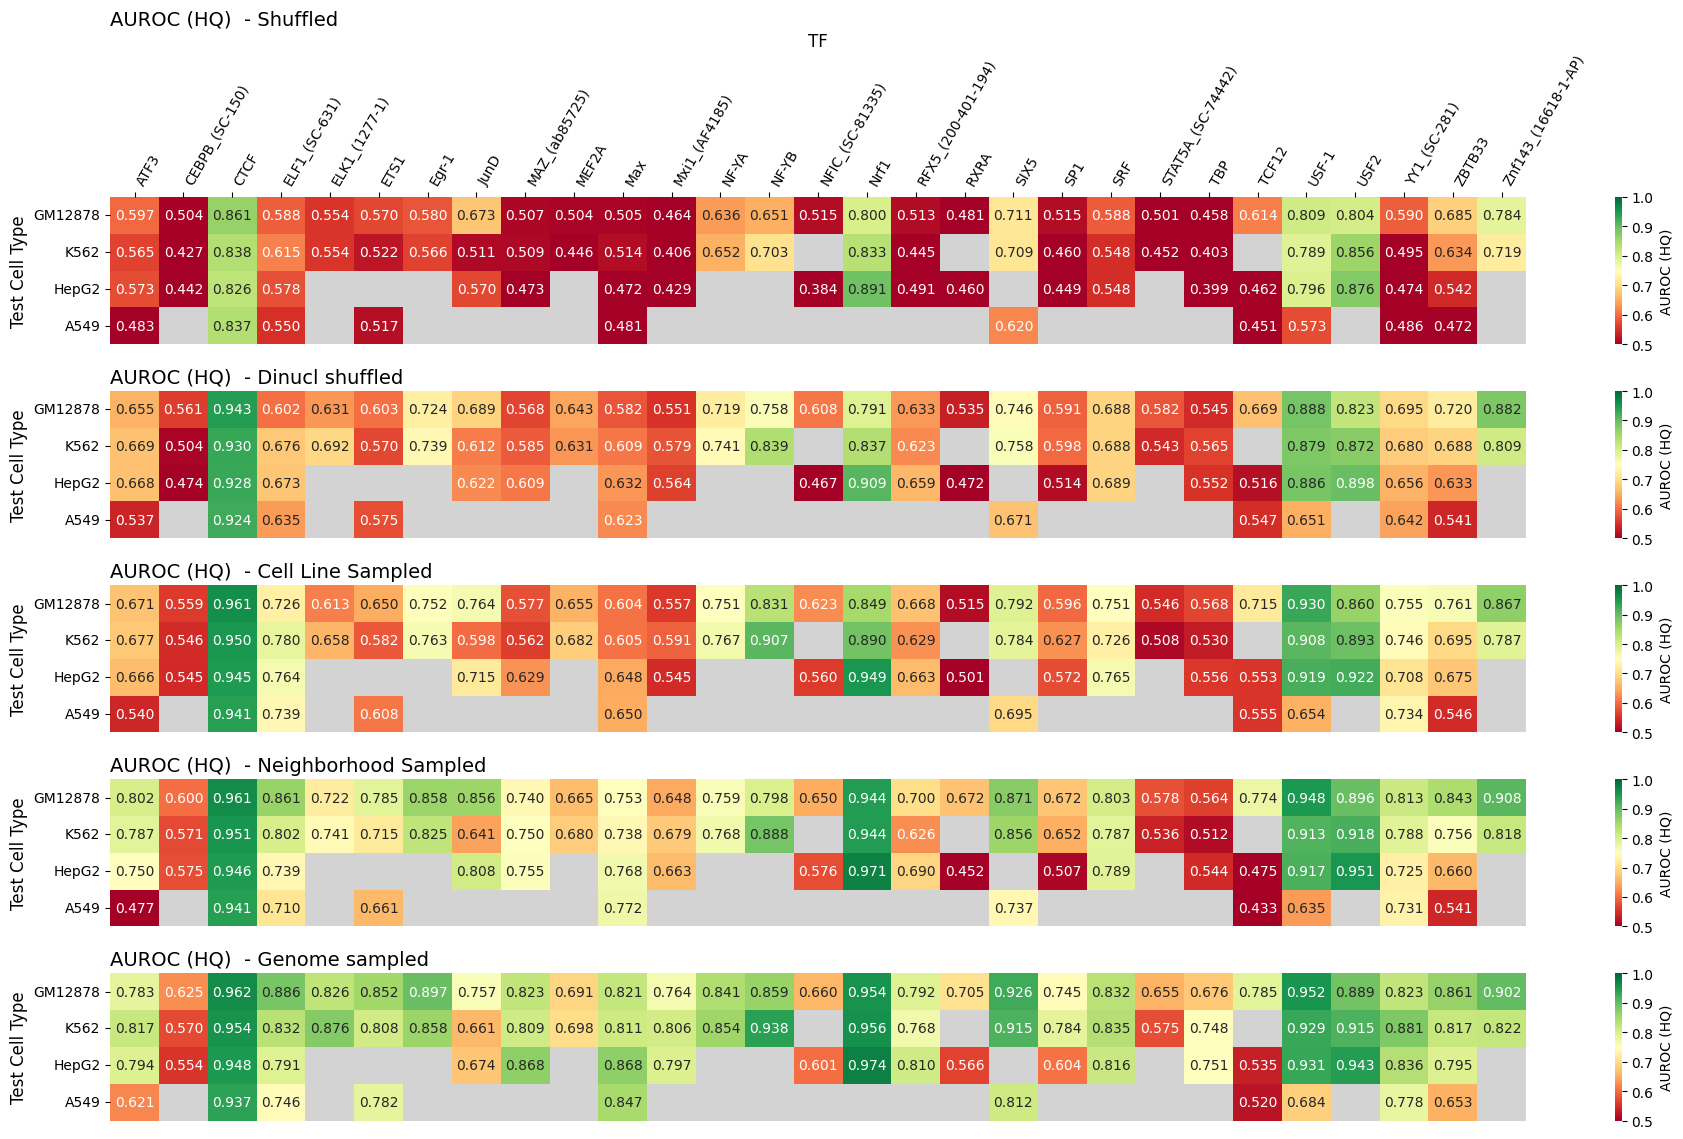

In [47]:
# Get unique neg_modes
neg_modes = ["Shuffled", "Dinucl shuffled", "Cell Line Sampled", "Neighborhood Sampled", "Genome sampled"]
metric = "AUROC_HQ"

# Option to filter TFs with data in at least N cell types
min_celltypes = 2  # Set to None to disable filtering, or an integer (e.g., 2, 3, 4)

# Create subplots - one row per neg_mode, shared x-axis
fig, axes = plt.subplots(len(neg_modes), 1, figsize=(19, 2.3*len(neg_modes)), sharex=True)

# If only one neg_mode, axes won't be an array, so wrap it
if len(neg_modes) == 1:
    axes = [axes]

# Create a heatmap for each neg_mode
for idx, neg_mode in enumerate(neg_modes):
    # Filter data for this neg_mode
    filtered_df = grouped_avg[grouped_avg['neg_mode'] == neg_mode]
    
    # Create pivot table with TF as columns and test_celltype as rows
    heatmap_data = filtered_df.pivot_table(
     values=metric, 
     index='test_celltype', 
     columns='TF', 
     aggfunc='mean'
    )
    
    # Filter TFs based on minimum cell type requirement
    if min_celltypes is not None:
        tfs_to_keep = heatmap_data.columns[heatmap_data.notna().sum() >= min_celltypes]
        heatmap_data = heatmap_data[tfs_to_keep]
    
    # Reorder rows with specified order
    desired_order = ['GM12878', 'K562', 'HepG2', 'A549']
    existing_celltypes = [ct for ct in desired_order if ct in heatmap_data.index]
    heatmap_data = heatmap_data.reindex(existing_celltypes)
    
    # Create heatmap with grey for missing values
    sns.heatmap(
     heatmap_data, 
     annot=True, 
     fmt='.3f', 
     cmap='RdYlGn', 
     ax=axes[idx],
     vmin=0.5,
     vmax=1.0,
     mask=heatmap_data.isna(),
     cbar_kws={'label': "AUROC (HQ)"}
    )
    
    # Fill grey for missing values
    axes[idx].patch.set_facecolor('lightgrey')
    
    # Only move x-axis labels to top for the first subplot
    if idx == 0:
        axes[idx].xaxis.tick_top()
        axes[idx].xaxis.set_label_position('top')
        axes[idx].set_xlabel('TF', fontsize=12)
        axes[idx].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
        # Rotate labels 90 degrees
        plt.setp(axes[idx].get_xticklabels(), rotation=60, ha='left')
    else:
        axes[idx].set_xlabel('')
        axes[idx].tick_params(bottom=False, labelbottom=False, top=False, labeltop=False)
        
    axes[idx].set_title(f'AUROC (HQ)  - {neg_mode}', fontsize=14)
    axes[idx].set_ylabel('Test Cell Type', fontsize=12)

    
plt.tight_layout()
plt.savefig("/data/home/natant/Negatives/figures/Cross_cell_line_HQ_AUROC_heatmaps.eps", format="eps", bbox_inches="tight")
plt.show()

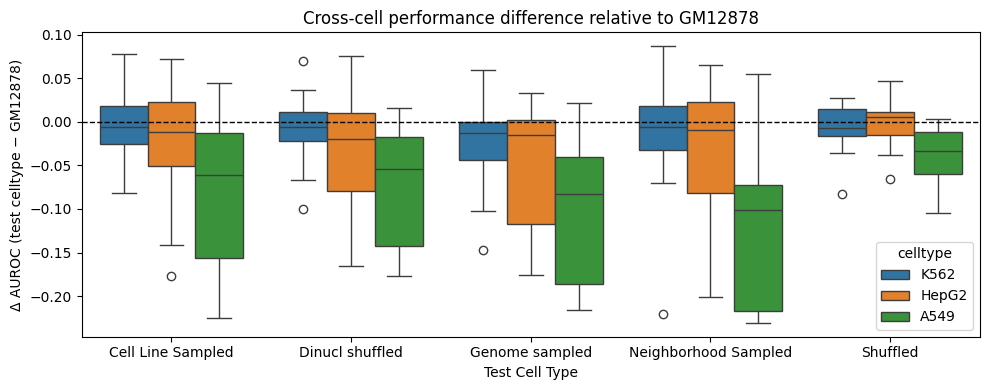

In [ ]:
# Compute mean AUROC per TF, neg_mode, *test* celltype
mean_perf = (
    grouped_avg
    .groupby(["TF", "neg_mode", "test_celltype"], as_index=False)["AUROC"]
    .mean()
)

# Pivot so that each row is (TF, neg_mode) and columns are test_celltypes
pivot_perf = mean_perf.pivot_table(
    index=["TF", "neg_mode"],
    columns="test_celltype",
    values="AUROC"
).reset_index()

# Only keep rows where GM12878 exists (reference)
pivot_perf = pivot_perf[pivot_perf["GM12878"].notna()]

# Compute differences: (other_celltype - GM12878)
for ct in ["K562", "HepG2", "A549"]:
    if ct in pivot_perf.columns:
        pivot_perf[f"diff_{ct}"] = pivot_perf[ct] - pivot_perf["GM12878"]

# Melt into long format for plotting
diff_cols = [c for c in pivot_perf.columns if c.startswith("diff_")]
long_diff = pivot_perf.melt(
    id_vars=["TF", "neg_mode"],
    value_vars=diff_cols,
    var_name="celltype",
    value_name="AUROC_diff"
)

# Clean up celltype names (from "diff_K562" -> "K562")
long_diff["celltype"] = long_diff["celltype"].str.replace("diff_", "")

# Drop rows where diff is NaN (no GM12878 or no target celltype value)
long_diff = long_diff.dropna(subset=["AUROC_diff"])

# Restrict x-axis to desired celltypes in a fixed order
order = ["K562", "HepG2", "A549"]
long_diff = long_diff[long_diff["celltype"].isin(order)]

plt.figure(figsize=(10, 4))
sns.boxplot(
    data=long_diff,
    hue="celltype",
    y="AUROC_diff",
    x="neg_mode",
    #order=order
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.ylabel("Δ AUROC (test celltype - GM12878)")
plt.xlabel("Test Cell Type")
plt.title("Cross-cell performance difference relative to GM12878")
plt.tight_layout()
plt.show()

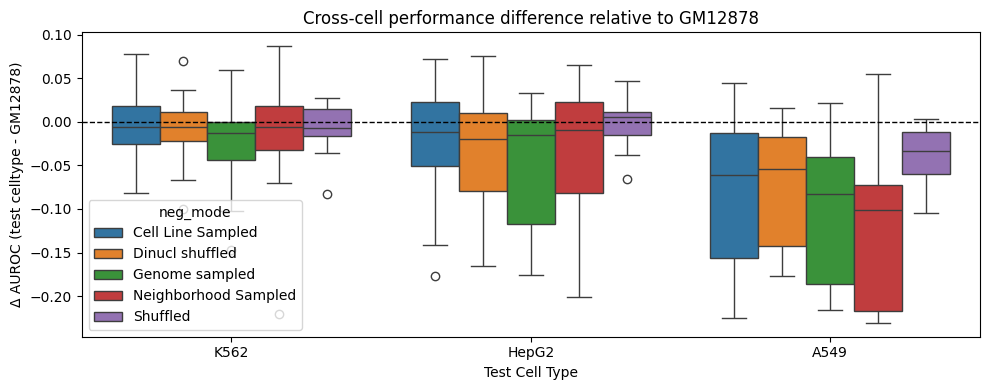

In [26]:
# Compute mean AUROC per TF, neg_mode, *test* celltype
mean_perf = (
    grouped_avg
    .groupby(["TF", "neg_mode", "test_celltype"], as_index=False)["AUROC"]
    .mean()
)

# Pivot so that each row is (TF, neg_mode) and columns are test_celltypes
pivot_perf = mean_perf.pivot_table(
    index=["TF", "neg_mode"],
    columns="test_celltype",
    values="AUROC"
).reset_index()

# Only keep rows where GM12878 exists (reference)
pivot_perf = pivot_perf[pivot_perf["GM12878"].notna()]

# Compute differences: (other_celltype - GM12878)
for ct in ["K562", "HepG2", "A549"]:
    if ct in pivot_perf.columns:
        pivot_perf[f"diff_{ct}"] = pivot_perf[ct] - pivot_perf["GM12878"]

# Melt into long format for plotting
diff_cols = [c for c in pivot_perf.columns if c.startswith("diff_")]
long_diff = pivot_perf.melt(
    id_vars=["TF", "neg_mode"],
    value_vars=diff_cols,
    var_name="celltype",
    value_name="AUROC_diff"
)

# Clean up celltype names (from "diff_K562" -> "K562")
long_diff["celltype"] = long_diff["celltype"].str.replace("diff_", "")

# Drop rows where diff is NaN (no GM12878 or no target celltype value)
long_diff = long_diff.dropna(subset=["AUROC_diff"])

# Restrict x-axis to desired celltypes in a fixed order
order = ["K562", "HepG2", "A549"]
long_diff = long_diff[long_diff["celltype"].isin(order)]

plt.figure(figsize=(10, 4))
sns.boxplot(
    data=long_diff,
    x="celltype",
    y="AUROC_diff",
    hue="neg_mode",
    #order=order
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.ylabel("Δ AUROC (test celltype - GM12878)")
plt.xlabel("Test Cell Type")
plt.title("Cross-cell performance difference relative to GM12878")
plt.tight_layout()
plt.show()

In [53]:
pivot_perf

test_celltype,TF,neg_mode,A549,GM12878,HepG2,K562,diff_K562,diff_HepG2,diff_A549,mean_delta
0,ATF2_(SC-81188),Cell Line Sampled,NaN,0.640860,NaN,NaN,NaN,NaN,NaN,NaN
1,ATF2_(SC-81188),Dinucl shuffled,NaN,0.783179,NaN,NaN,NaN,NaN,NaN,NaN
2,ATF2_(SC-81188),Genome sampled,NaN,0.791551,NaN,NaN,NaN,NaN,NaN,NaN
3,ATF2_(SC-81188),Neighborhood Sampled,NaN,0.699562,NaN,NaN,NaN,NaN,NaN,NaN
4,ATF2_(SC-81188),Shuffled,NaN,0.940852,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
170,Znf143_(16618-1-AP),Cell Line Sampled,NaN,0.837637,NaN,0.775786,-0.061851,NaN,NaN,-0.061851
171,Znf143_(16618-1-AP),Dinucl shuffled,NaN,0.917445,NaN,0.858841,-0.058604,NaN,NaN,-0.058604
172,Znf143_(16618-1-AP),Genome sampled,NaN,0.942527,NaN,0.879252,-0.063276,NaN,NaN,-0.063276
173,Znf143_(16618-1-AP),Neighborhood Sampled,NaN,0.929617,NaN,0.859304,-0.070313,NaN,NaN,-0.070313


In [54]:
# Compute mean AUROC per TF, neg_mode, *test* celltype
mean_perf = (
    grouped_avg
    .groupby(["TF", "neg_mode", "test_celltype"], as_index=False)["AUROC"]
    .mean()
)

# Pivot so that each row is (TF, neg_mode) and columns are test_celltypes
pivot_perf = mean_perf.pivot_table(
    index=["TF", "neg_mode"],
    columns="test_celltype",
    values="AUROC"
).reset_index()

# Keep only rows where GM12878 exists (reference)
pivot_perf = pivot_perf[pivot_perf["GM12878"].notna()]

# Compute deltas (other_celltype - GM12878)
for ct in ["K562", "HepG2", "A549"]:
    if ct in pivot_perf.columns:
        pivot_perf[f"diff_{ct}"] = pivot_perf[ct] - pivot_perf["GM12878"]

# Average delta across all available non-null celltypes per TF/neg_mode
diff_cols = [c for c in pivot_perf.columns if c.startswith("diff_")]
pivot_perf["mean_delta"] = pivot_perf[diff_cols].mean(axis=1, skipna=True)

# Now aggregate over neg_mode: mean of mean_delta for each TF
tf_mean_delta = (
    pivot_perf
    .groupby("TF", as_index=False)["mean_delta"]
    .mean()
    .rename(columns={"mean_delta": "TF_mean_delta"})
)

# Order TFs from lowest to highest mean delta
tf_mean_delta_sorted = tf_mean_delta.sort_values("TF_mean_delta").reset_index(drop=True)

tf_mean_delta_sorted

,TF,TF_mean_delta
0,TCF12,-0.144739
1,NFIC_(SC-81335),-0.114235
2,JunD,-0.104521
3,ZBTB33,-0.095732
4,USF-1,-0.059678
5,ATF3,-0.059526
6,Znf143_(16618-1-AP),-0.052360
7,SP1,-0.052027
8,ETS1,-0.043924
9,RXRA,-0.043435


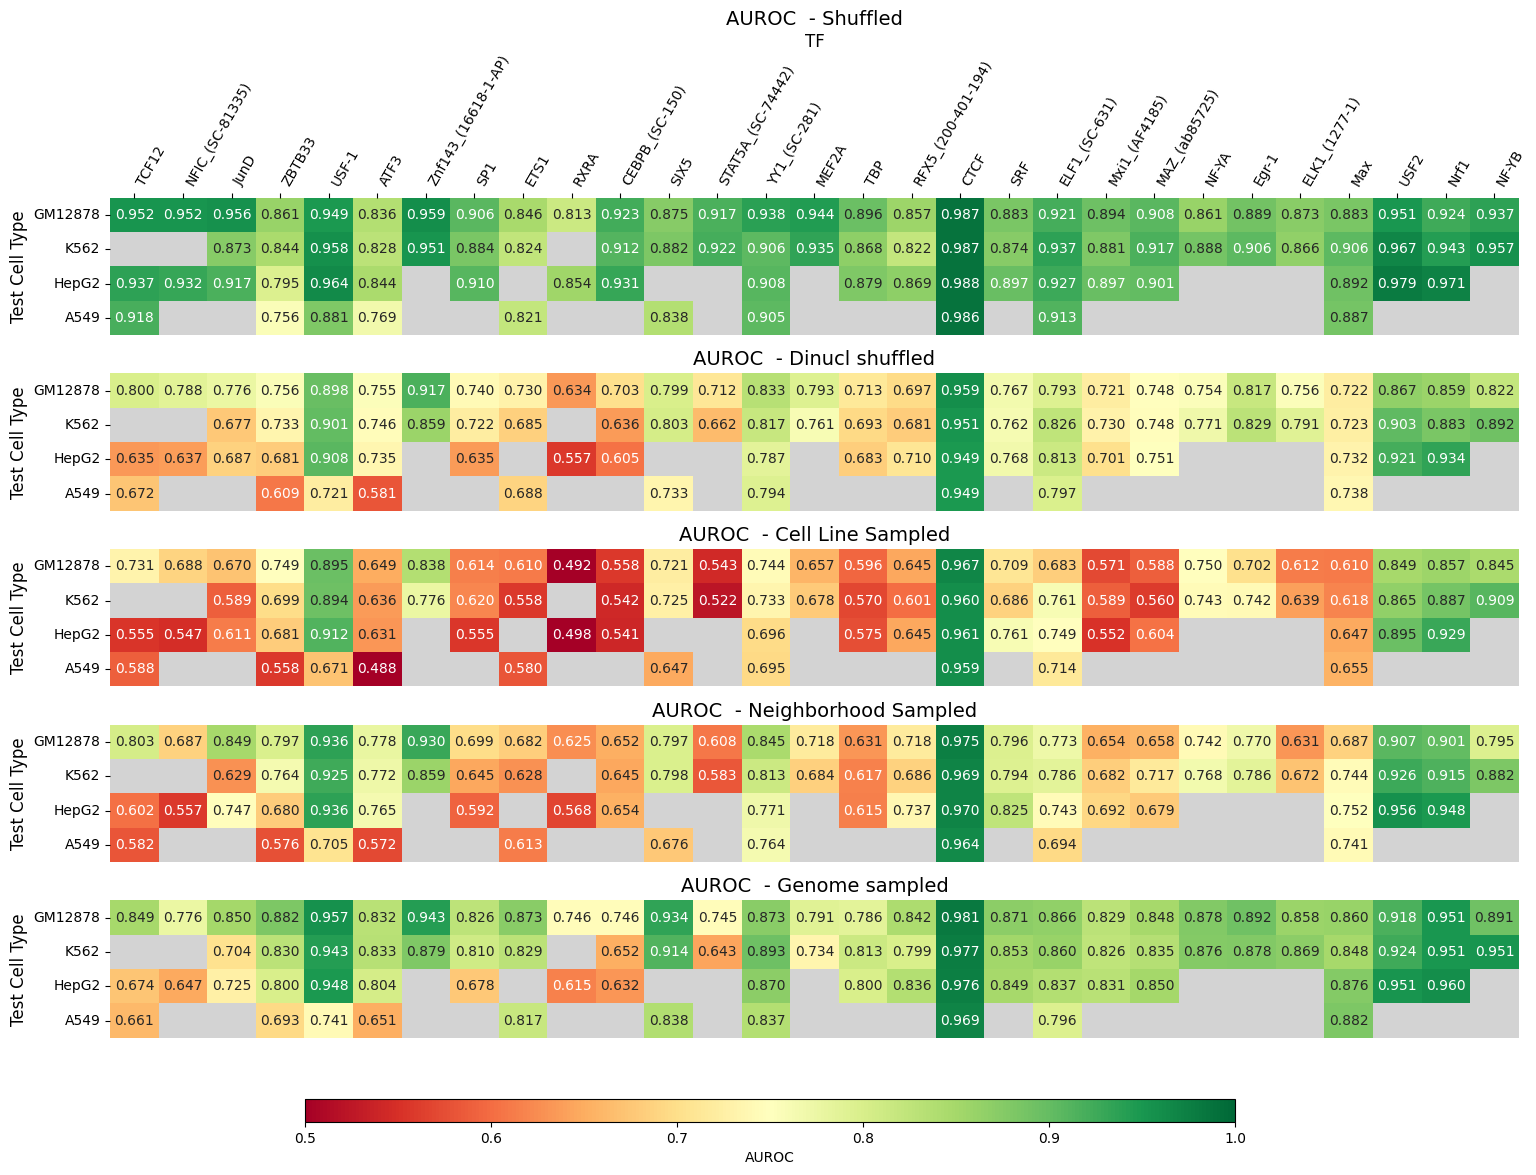

In [57]:
# Get unique neg_modes
neg_modes = ["Shuffled", "Dinucl shuffled", "Cell Line Sampled", "Neighborhood Sampled", "Genome sampled"]
metric = "AUROC"
# Recompute tf_order_abs (mean ΔAUROC across non-GM12878 test cell types, per TF)

# Compute mean AUROC per TF, neg_mode, *test* celltype
mean_perf = (
    grouped_avg
    .groupby(["TF", "neg_mode", "test_celltype"], as_index=False)["AUROC"]
    .mean()
)

# Pivot so that each row is (TF, neg_mode) and columns are test_celltypes
pivot_perf = mean_perf.pivot_table(
    index=["TF", "neg_mode"],
    columns="test_celltype",
    values="AUROC"
).reset_index()

# Keep only rows where GM12878 exists (reference)
pivot_perf = pivot_perf[pivot_perf["GM12878"].notna()]

# Compute deltas (other_celltype - GM12878)
for ct in ["K562", "HepG2", "A549"]:
    if ct in pivot_perf.columns:
        pivot_perf[f"diff_{ct}"] = pivot_perf[ct] - pivot_perf["GM12878"]

# Average delta across all available non-null celltypes per TF/neg_mode
diff_cols = [c for c in pivot_perf.columns if c.startswith("diff_")]
pivot_perf["mean_delta"] = pivot_perf[diff_cols].mean(axis=1, skipna=True)

# Now aggregate over neg_mode: mean of mean_delta for each TF
tf_mean_delta = (
    pivot_perf
    .groupby("TF", as_index=False)["mean_delta"]
    .mean()
    .rename(columns={"mean_delta": "TF_mean_delta"})
)

# Order TFs from lowest to highest mean delta
tf_mean_delta_sorted = tf_mean_delta.sort_values("TF_mean_delta").reset_index(drop=True)

# Absolute order of TFs for plotting
tf_order_abs = tf_mean_delta_sorted["TF"].tolist()

# Option to filter TFs with data in at least N cell types
min_celltypes = 2  # Set to None to disable filtering, or an integer (e.g., 2, 3, 4)

# Create subplots - one row per neg_mode, shared x-axis
fig, axes = plt.subplots(len(neg_modes), 1, figsize=(15.5, 2.3 * len(neg_modes)), sharex=True)

# If only one neg_mode, axes won't be an array, so wrap it
if len(neg_modes) == 1:
    axes = [axes]

im = None  # will hold the mappable for the global colorbar

# Create a heatmap for each neg_mode
for idx, neg_mode in enumerate(neg_modes):
    # Filter data for this neg_mode
    filtered_df = grouped_avg[grouped_avg['neg_mode'] == neg_mode]
    
    # Create pivot table with TF as columns and test_celltype as rows
    heatmap_data = filtered_df.pivot_table(
        values=metric,
        index='test_celltype',
        columns='TF',
        aggfunc='mean'
    )
    
    # Filter TFs based on minimum cell type requirement
    if min_celltypes is not None:
        tfs_to_keep = heatmap_data.columns[heatmap_data.notna().sum() >= min_celltypes]
        heatmap_data = heatmap_data[tfs_to_keep]

    # Reorder TFs according to tf_order_abs, keeping only those in this heatmap
    col_order = [tf for tf in tf_order_abs if tf in heatmap_data.columns]
    heatmap_data = heatmap_data[col_order]

    # Reorder rows with specified order
    desired_order = ['GM12878', 'K562', 'HepG2', 'A549']
    existing_celltypes = [ct for ct in desired_order if ct in heatmap_data.index]
    heatmap_data = heatmap_data.reindex(existing_celltypes)
    
    # Create heatmap WITHOUT individual colorbars
    im = sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        ax=axes[idx],
        vmin=0.5,
        vmax=1.0,
        mask=heatmap_data.isna(),
        cbar=False
    )
    
    # Fill grey for missing values
    axes[idx].patch.set_facecolor('lightgrey')
    
    # Only move x-axis labels to top for the first subplot
    if idx == 0:
        axes[idx].xaxis.tick_top()
        axes[idx].xaxis.set_label_position('top')
        axes[idx].set_xlabel('TF', fontsize=12)
        axes[idx].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
        plt.setp(axes[idx].get_xticklabels(), rotation=60, ha='left')
    else:
        axes[idx].set_xlabel('')
        axes[idx].tick_params(bottom=False, labelbottom=False, top=False, labeltop=False)
    
    axes[idx].set_title(f'{metric}  - {neg_mode}', fontsize=14, loc='center')
    axes[idx].set_ylabel('Test Cell Type', fontsize=12)

# Add a single colorbar at the bottom using the last heatmap's mappable
fig.tight_layout(rect=[0, 0.08, 1, 1])

cbar_ax = fig.add_axes([0.2, 0.02, 0.6, 0.02])
cbar = fig.colorbar(im.collections[0], cax=cbar_ax, orientation='horizontal')
cbar.set_label(metric)

plt.savefig("/data/home/natant/Negatives/figures/Cross_cell_line_AUROC_heatmaps.eps",
            format="eps", bbox_inches="tight")
plt.show()
